## Imports

In [1]:
import psycopg2 
import pandas as pd
import numpy as np 
from faker import Faker
import os
from dotenv import load_dotenv
from datetime import timedelta
from psycopg2.extras import execute_values

## Database Connection|

In [2]:
load_dotenv()
conn_string = os.getenv('NEON_URL')

conn = psycopg2.connect(conn_string)
cur = conn.cursor()

cur.execute("SELECT version();" )
print(cur.fetchone())

python-dotenv could not parse statement starting at line 7


('PostgreSQL 17.8 (92d3c18) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit',)


## Table Queries

In [3]:
tables_query = """
SELECT 
    table_schema, table_name
FROM 
    information_schema.tables
WHERE 
    table_schema NOT IN ('pg_catalog', 'information_schema')
ORDER BY 
    table_schema, table_name;
"""
df_tables = pd.read_sql(tables_query, conn)
df_tables

/var/folders/5y/20qzsxn55txdbxf0jcdh23h00000gn/T/ipykernel_54255/3562565850.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(tables_query, conn)


,table_schema,table_name
0,public,arrival_method
1,public,department
2,public,outcome
3,public,patient
4,public,triage_category
5,public,visit


## Variables

In [4]:
# Taken from the nhs admission analysis notebook.

admission_baseline = {
    'avg_ae_attendances': 12006 * 12,
    'avg_within_4hrs': 8928 * 12,
    'avg_over_4hrs': 3078 * 12,
    'avg_emergency_admissions': 2865 * 12,
    'avg_admission_rate': 18.02,
    'avg_dta_4_12hrs': 446 * 12,
    'avg_dta_12plus_hrs': 254 * 12
}


config = {
    'n_months': 12,
    'start_date': '2025-04-01',
    'department_name': 'Emergency Department',
    'n_patients': 100000,
    'baseline': admission_baseline,
    'n_clinicians': 40,
    'org_name': 'Synthetic NHS Trust',
    'parent_org': 'Synthetic NHS Region',
}

triage_probs = {
    1: 0.0002,
    2: 0.005,
    3: 0.249,
    4: 0.547,
    5: 0.199,
} # Taken from https://pmc.ncbi.nlm.nih.gov/articles/PMC6805326/

triage_probs = {k: v / sum(triage_probs.values()) for k, v in triage_probs.items()}


p_over_4hrs = config['baseline']['avg_over_4hrs'] / config['baseline']['avg_ae_attendances']
p_admitted = config['baseline']['avg_emergency_admissions'] / config['baseline']['avg_ae_attendances']

admitted_total = config['baseline']['avg_emergency_admissions']
p_dta_4_12 = config['baseline']['avg_dta_4_12hrs'] / admitted_total
p_dta_12plus = config['baseline']['avg_dta_12plus_hrs'] / admitted_total
p_dta_none = 1 - (p_dta_4_12 + p_dta_12plus)

p_over_4hrs, p_admitted, p_dta_4_12, p_dta_12plus, p_dta_none
 

(0.2563718140929535,
 0.23863068465767118,
 0.1556719022687609,
 0.08865619546247819,
 0.7556719022687609)

# Hardcoded Lookup Values

In [5]:
department_df = pd.DataFrame({'department_id': 1, 'department_name': [config['department_name']]})
department_df.to_csv('../data/synthetic/_department.csv', index=False)

In [6]:
triage_df = pd.DataFrame([
    {'triage_id': 1, 'triage_name': 'Life Threatening Conditions', 'priority': 1},
    {'triage_id': 2, 'triage_name': 'Very Urgent', 'priority': 2},
    {'triage_id': 3, 'triage_name': 'Urgent', 'priority': 3},
    {'triage_id': 4, 'triage_name': 'Not Threatening to Life & Limb', 'priority': 4},
    {'triage_id': 5, 'triage_name':  'Not Urgent', 'priority': 5},
])
triage_df.to_csv('../data/synthetic/_triage.csv', index=False)

In [7]:
arrival_method_df = pd.DataFrame([
    {'arrival_method_id': 1, 'arrival_method_name': 'Ambulance'},
    {'arrival_method_id': 2, 'arrival_method_name': 'Walk-in'},
    {'arrival_method_id': 3, 'arrival_method_name': 'GP'},
    {'arrival_method_id': 4, 'arrival_method_name': 'NHS 111'},
    {'arrival_method_id': 5, 'arrival_method_name': 'Police/Other Emergency Services'},
    {'arrival_method_id': 6, 'arrival_method_name': 'Other'},
])
arrival_method_df.to_csv('../data/synthetic/_arrival_method.csv', index=False)

In [8]:
outcome_df = pd.DataFrame([
    {'outcome_id': 1, 'outcome_name': 'Discharged'},
    {'outcome_id': 2, 'outcome_name': 'Admitted'},
    {'outcome_id': 3, 'outcome_name': 'Transferred'},
    {'outcome_id': 4, 'outcome_name': 'Left Before Treatment Complete'},
])
outcome_df.to_csv('../data/synthetic/_outcome.csv', index=False)

## Synthetic data

### Patient Rows

In [9]:
postcode_areas = ['E', 'N', 'NW', 'SE', 'SW', 'W', 'WC']
sex_values = ['Male', 'Female', 'Other', 'Unknown']
sex_probs = [0.48, 0.48, 0.02, 0.02]

patients = []
for patient_num in range(1, config['n_patients'] + 1):
    age = np.random.randint(1, 100)
    dob = pd.Timestamp('2026-01-01') - pd.DateOffset(years=age) + pd.DateOffset(days=np.random.randint(0, 365))
    sex = np.random.choice(sex_values, p=sex_probs)
    
    patients.append({
        'patient_id': patient_num,
        'date_of_birth': dob.date(),
        'sex': sex,
        'postcode_area': np.random.choice(postcode_areas),
    })
    
    
    
patients_df = pd.DataFrame(patients)
patients_df.to_csv('../data/synthetic/_patients.csv', index=False)


### Visits

#### Probability and Time to Assessent Distribution

Distributions are taken from https://pmc.ncbi.nlm.nih.gov/articles/PMC6805326/

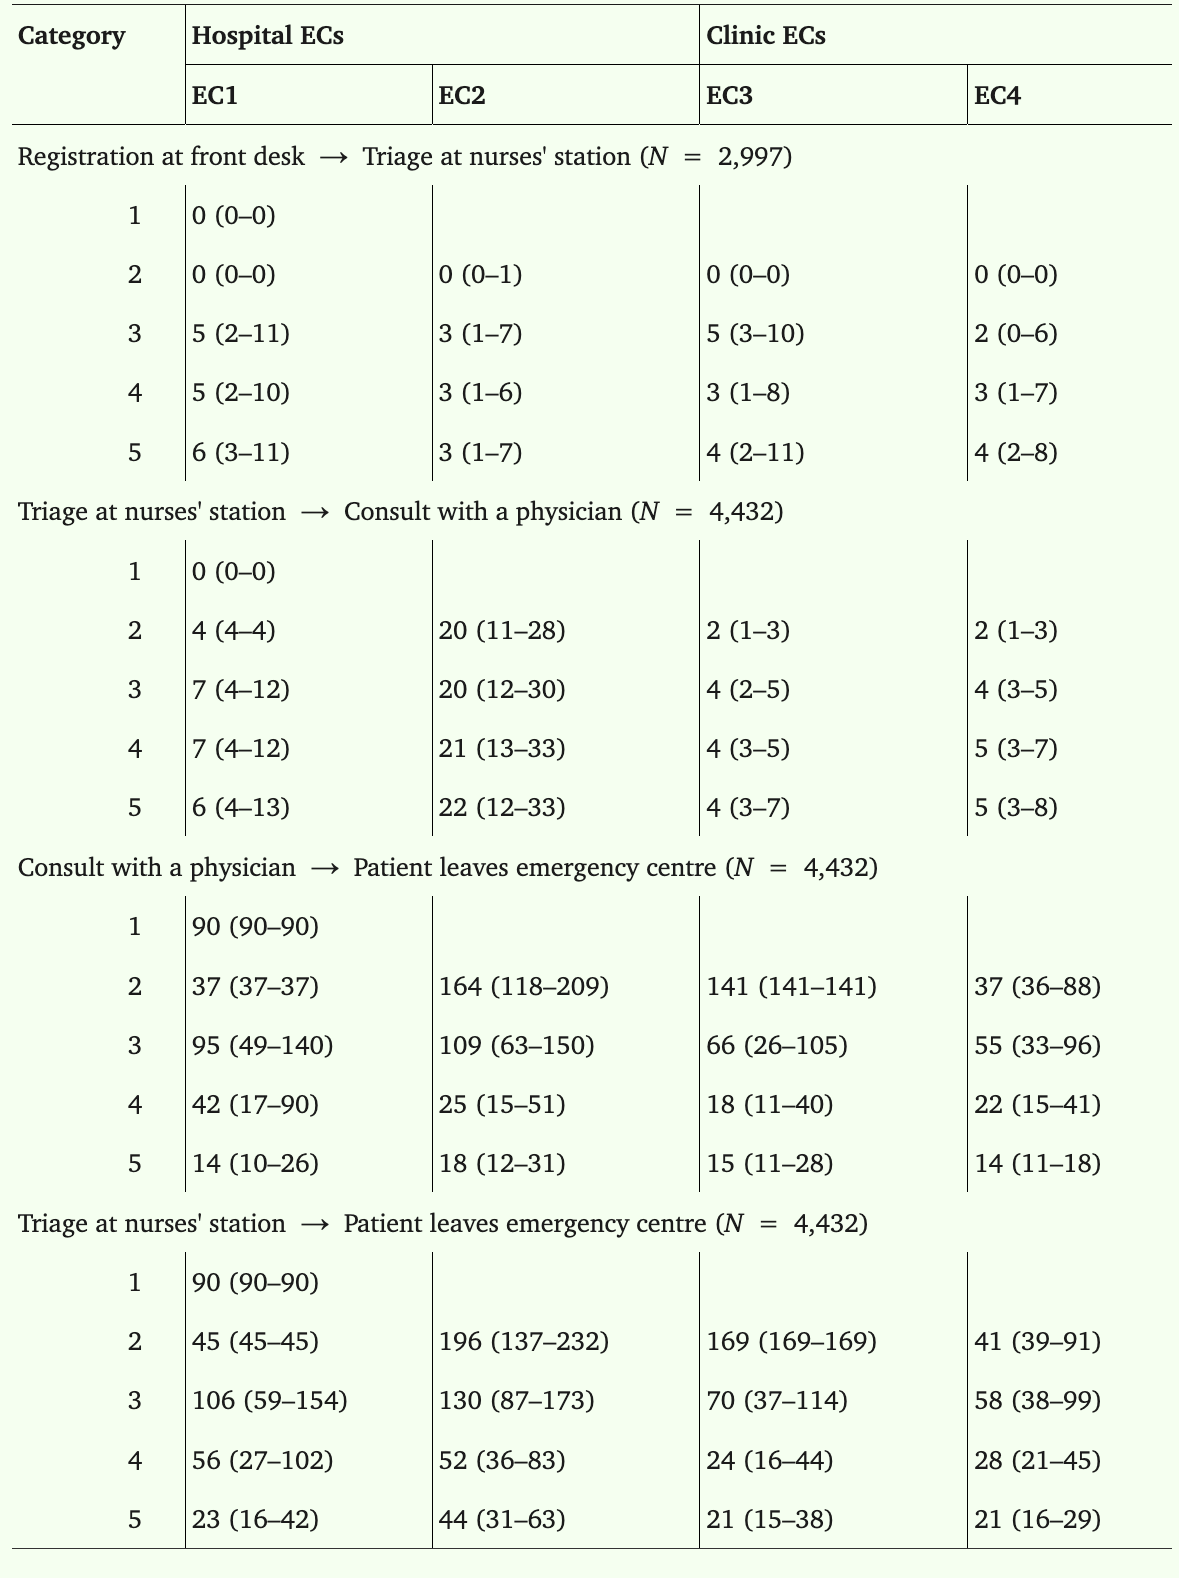

In [10]:
n_visits = int(config['baseline']['avg_ae_attendances']) # Total num of visits to generate based on NHS stats

# Visits are made uniformly across the time range 
start = pd.Timestamp(config['start_date'])
end = start + pd.DateOffset(months=config['n_months'])
seconds_range = int((end - start).total_seconds())

# Generate initial viist data without timestamps or outcomes. 
visit_stage = pd.DataFrame({
    'visit_id': range(1, n_visits + 1),
    'patient_id': np.random.randint(1, config['n_patients'] + 1, size=n_visits),
    'triage_id': np.random.choice(
        list(triage_probs.keys()),
        size=n_visits,
        p=list(triage_probs.values())
    ),
    'arrival_method_id': np.random.randint(1, 7, size=n_visits),
    'department_id': 1,
})

# The arrival time is taken as a random point in time during the range
visit_stage['arrival_time'] = start + pd.to_timedelta(
    np.random.randint(0, seconds_range, size=n_visits),
    unit='s'
)

# Flag to indicate if the patient was admitted or not, based on the admission rate from NHS
visit_stage['is_admitted'] = np.random.choice(
    [0, 1],
    size=n_visits,
    p=[1 - p_admitted, p_admitted]
)

# Flag to indicate if the visit was over 4hr from NHS
visit_stage['is_over_4hrs'] = np.random.choice(
    [0, 1],
    size=n_visits,
    p=[1 - p_over_4hrs, p_over_4hrs]
)

# Iniitially set all to not admitted, delay bands will only be relevant for admitted patients, which will dictate the timestamps. 
visit_stage['dta_delay_band'] = 'not_admitted'

# For admitted patients, assign a delay randomly based on NHS proportions.
admitted_mask = visit_stage['is_admitted'] == 1
visit_stage.loc[admitted_mask, 'dta_delay_band'] = np.random.choice(
    ['none', '4_12hrs', '12plus_hrs'],
    size=admitted_mask.sum(),
    p=[p_dta_none, p_dta_4_12, p_dta_12plus]
)

# Determine the outcome based on admission and other random factors to variate data.
rand_transfer = np.random.rand(n_visits)
rand_left = np.random.rand(n_visits)

visit_stage['outcome_id'] = np.select(
    [
        visit_stage['is_admitted'] == 1,
        (visit_stage['is_admitted'] == 0) & (rand_transfer < 0.05),
        (visit_stage['is_admitted'] == 0) & (rand_left < 0.03),
    ],
    [
        2,  # admitted
        3,  # transferred
        4,  # left before treatment complete
    ],
    default=1  # discharged
)

visit_stage.head()

,visit_id,patient_id,triage_id,arrival_method_id,department_id,arrival_time,is_admitted,is_over_4hrs,dta_delay_band,outcome_id
0,1,26761,4,2,1,2025-12-13 06:12:11,0,0,not_admitted,1
1,2,72587,4,2,1,2025-08-11 20:06:52,0,1,not_admitted,1
2,3,18438,5,4,1,2025-04-18 19:35:18,0,0,not_admitted,1
3,4,74625,4,2,1,2025-06-04 12:54:34,0,0,not_admitted,1
4,5,5293,4,1,1,2025-06-10 11:57:23,0,0,not_admitted,1


In [11]:
def sample_total_visit_minutes(is_admitted, is_over_4hrs, dta_delay_band):
    '''
    Decides the total duration of the hospital stay 
    
    :param is_admitted: whether the patient was admitted or not
    :param is_over_4hrs: whether the visit was over 4 hours or not
    :param dta_delay_band: the delay band for admitted patients (none, 4-12hrs, 12+hrs)
    '''
    
    if is_admitted == 1:
        if dta_delay_band == '12plus_hrs':
            return np.random.randint(720, 1441)   # 12 to 24 hours
        elif dta_delay_band == '4_12hrs':
            return np.random.randint(240, 721)    # 4 to 12 hours
        elif is_over_4hrs == 1:
            return np.random.randint(240, 480)    # admitted and over 4 hours
        else:
            return np.random.randint(120, 240)    # admitted within 4 hours
    else:
        if is_over_4hrs == 1:
            return np.random.randint(240, 600)    # non-admitted amd over 4 hours
        else:
            return np.random.randint(30, 240)     # non-admitted within 4 hours


def sample_assessment_delay(triage_id, total_minutes):
    '''
    Samples delay from arrival to first assessment based on triage category and total visit duration. 
    
    :param triage_id: the triage category of the visit (1-5)
    :param total_minutes: the total duration of the visit in minuted
    '''
    if triage_id == 1:
        upper = min(5, max(1, total_minutes // 20))
        return np.random.randint(0, upper + 1) # high priority, delay is capped at 5 minutes 
    elif triage_id == 2:
        upper = min(10, max(2, total_minutes // 15))
        return np.random.randint(0, upper + 1) # urgent but not life threatening, delay is capped at 10 minutes
    elif triage_id == 3:
        upper = min(20, max(5, total_minutes // 10))
        return np.random.randint(3, upper + 1) # urgent but not life threatening, delay is between 3 and 20 minutes
    elif triage_id == 4:
        upper = min(30, max(8, total_minutes // 8))
        return np.random.randint(5, upper + 1) # not threatening to life, delay is between 5 and 30 minutes
    else:
        upper = min(45, max(10, total_minutes // 6))
        return np.random.randint(8, upper + 1) # least urgent, delay is between 8 and 45 minutes


def sample_treatment_delay(triage_id, assessment_delay, total_minutes, outcome_id):
    '''
    Samples delay from first assessment to treatment start based on the assessment delay, the total visit duration, and the outcome
    
    :param triage_id: the triage category of the visit (1-5)
    :param assessment_delay: the delay from arrival to first assessment in minutes
    :param total_minutes: the total duration of the visit in minutes
    :param outcome_id: the outcome of the visit (1-4)
    '''
    if outcome_id == 4:  # left before treatment complete
        return pd.NaT
    
    remaining = total_minutes - assessment_delay
    if remaining <= 2:
        return assessment_delay + 1
    
    if triage_id == 1:          # life threatening
        frac = np.random.uniform(0.05, 0.15)
    elif triage_id == 2:        # very urgent
        frac = np.random.uniform(0.08, 0.20)
    elif triage_id == 3:        # urgent
        frac = np.random.uniform(0.15, 0.30)
    elif triage_id == 4:        # not threatening to life & limb
        frac = np.random.uniform(0.25, 0.45)
    else:                       # not urgent
        frac = np.random.uniform(0.35, 0.60)
    
    frac = np.random.uniform(0.15, 0.45)
    treatment_delay = assessment_delay + int(round(remaining * frac))
    treatment_delay = min(treatment_delay, total_minutes - 1)
    return treatment_delay


def make_timestamps(df):
    '''
    Makes the timestamps for first assessment, treatment start, and discharge. 
    
    :param df: the dataframe 
    '''
    first_assessment_times = []
    treatment_start_times = []
    discharge_times = []

    for _, row in df.iterrows():
        total_minutes = sample_total_visit_minutes(
            row['is_admitted'], 
            row['is_over_4hrs'],
            row['dta_delay_band']
        )

        assessment_delay = sample_assessment_delay(row['triage_id'], total_minutes)
        treatment_delay = sample_treatment_delay(
            row['triage_id'],
            assessment_delay,
            total_minutes,
            row['outcome_id']
        )

        first_assessment_time = row['arrival_time'] + pd.to_timedelta(assessment_delay, unit='m')
        discharge_time = row['arrival_time'] + pd.to_timedelta(total_minutes, unit='m')

        if pd.isna(treatment_delay):
            treatment_start_time = pd.NaT
        else:
            treatment_start_time = row['arrival_time'] + pd.to_timedelta(treatment_delay, unit='m')

        first_assessment_times.append(first_assessment_time)
        treatment_start_times.append(treatment_start_time)
        discharge_times.append(discharge_time)

    df['first_assessment_time'] = first_assessment_times
    df['treatment_start'] = treatment_start_times
    df['discharge_time'] = discharge_times

    return df


visit_stage = make_timestamps(visit_stage)
visit_stage.head()

,visit_id,patient_id,triage_id,arrival_method_id,department_id,arrival_time,is_admitted,is_over_4hrs,dta_delay_band,outcome_id,first_assessment_time,treatment_start,discharge_time
0,1,26761,4,2,1,2025-12-13 06:12:11,0,0,not_admitted,1,2025-12-13 06:30:11,2025-12-13 07:30:11,2025-12-13 09:04:11
1,2,72587,4,2,1,2025-08-11 20:06:52,0,1,not_admitted,1,2025-08-11 20:25:52,2025-08-11 23:50:52,2025-08-12 05:17:52
2,3,18438,5,4,1,2025-04-18 19:35:18,0,0,not_admitted,1,2025-04-18 20:03:18,2025-04-18 20:40:18,2025-04-18 22:40:18
3,4,74625,4,2,1,2025-06-04 12:54:34,0,0,not_admitted,1,2025-06-04 13:01:34,2025-06-04 13:19:34,2025-06-04 14:13:34
4,5,5293,4,1,1,2025-06-10 11:57:23,0,0,not_admitted,1,2025-06-10 12:07:23,2025-06-10 12:26:23,2025-06-10 13:35:23


In [12]:
visit_df = visit_stage[
    [
        'visit_id',
        'patient_id',
        'triage_id',
        'arrival_method_id',
        'department_id',
        'arrival_time',
        'first_assessment_time',
        'treatment_start',
        'discharge_time',
        'outcome_id'
    ]
].copy()
visit_df.to_csv('../data/synthetic/_visit.csv', index=False)


# Database Insertion

In [13]:
def insert_df(conn, df, table_name, conflict_col=None, delete_first=False, use_truncate=False):
    df = df.copy().astype(object).where(pd.notnull(df), None)
    cols = list(df.columns)
    values = [tuple(x) for x in df.to_numpy()]

    with conn.cursor() as cur:
        if delete_first:
            if use_truncate:
                cur.execute(f'TRUNCATE TABLE {table_name} RESTART IDENTITY CASCADE;')
            else:
                cur.execute(f'DELETE FROM {table_name};')

        query = f'INSERT INTO {table_name} ({', '.join(cols)}) VALUES %s'

        if conflict_col:
            query += f' ON CONFLICT ({conflict_col}) DO NOTHING'

        execute_values(cur, query, values)

    conn.commit()
    

In [14]:
insert_df(conn, department_df, 'department', delete_first=True, use_truncate=True)
insert_df(conn, triage_df, 'triage_category', delete_first=True, use_truncate=True)
insert_df(conn, arrival_method_df, 'arrival_method', delete_first=True, use_truncate=True)
insert_df(conn, outcome_df, 'outcome', delete_first=True, use_truncate=True)
insert_df(conn, patients_df, 'patient', delete_first=True, use_truncate=True)
insert_df(conn, visit_df, 'visit', delete_first=True, use_truncate=True)